In [ ]:
import pandas as pd

df = pd.read_excel('PriceHistory.xlsx')
df.head()

,Price History: Multiple Securities,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date,US Treasury Constant Maturity - 3 Month (CMTUS...,S&P 500 (SP50),American Airlines Group Inc. (AAL-US),Exxon Mobil Corporation (XOM-US),"Alexandria Real Estate Equities, Inc. (ARE-US)",Alphabet Inc. Class A (GOOGL-US),Lockheed Martin Corporation (LMT-US)
2,2026-04-09 00:00:00,3.68,6824.65727,11.37,155.04,43.99,318.49,623.87
3,2026-04-08 00:00:00,3.69,6782.811673,11.41,156.22,44.84,317.32,628.5
4,2026-04-07 00:00:00,3.71,6616.850835,10.81,163.91,44.13,305.46,627.7


In [ ]:
df.columns = df.iloc[1]
df = df.drop([0, 1])

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.columns = [
    'Date',
    'Risk_Free_Rate',
    'SP500',
    'AAL',
    'XOM',
    'ARE',
    'GOOGL',
    'LMT'
]

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [ ]:
df = df.apply(pd.to_numeric, errors='coerce')

In [ ]:
returns = df.pct_change().dropna()

In [ ]:
returns.describe()

,Risk_Free_Rate,SP500,AAL,XOM,ARE,GOOGL,LMT
count,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000
mean,0.000600,-0.000344,0.001029,-0.000670,0.001275,-0.000633,-0.000279
std,0.108550,0.010650,0.029974,0.016919,0.020460,0.019439,0.014470
min,-0.750000,-0.086886,-0.184353,-0.060250,-0.104539,-0.092760,-0.082010
25%,-0.002616,-0.006063,-0.014599,-0.011343,-0.010041,-0.011235,-0.007229
50%,0.000000,-0.000750,0.000514,-0.001159,0.000000,-0.001357,-0.000548
75%,0.002326,0.004753,0.017218,0.008902,0.010591,0.009719,0.005887
max,2.000000,0.063547,0.169295,0.085603,0.237210,0.105087,0.133831


In [ ]:
rf = df['Risk_Free_Rate'] / 100 / 252

In [ ]:
stocks = returns[['AAL', 'XOM', 'ARE', 'GOOGL', 'LMT']]
market = returns['SP500']

In [ ]:
## Here we create a df showing rolling volatility by individual stock
import numpy as np

stocks_volatility = stocks.rolling(window=252).std() * np.sqrt(252)

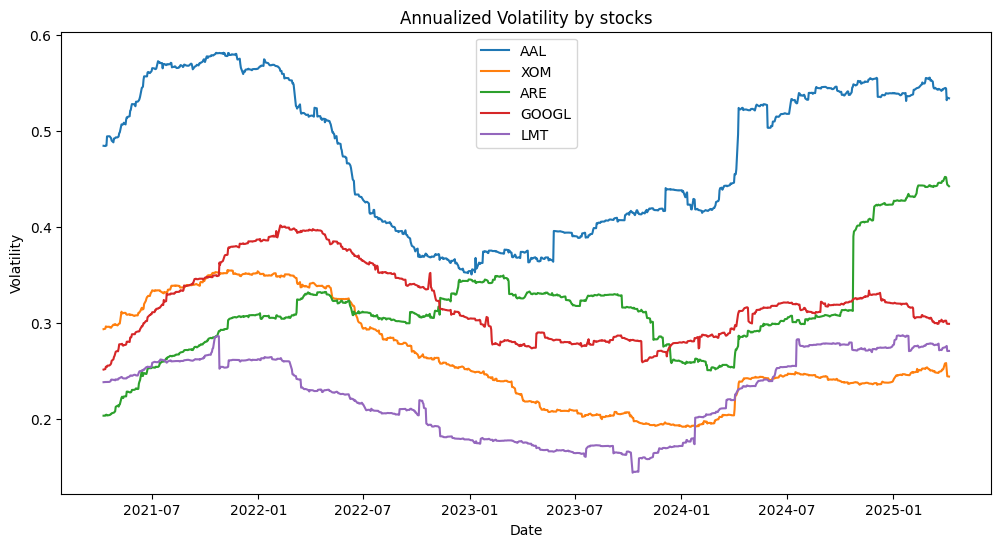

In [ ]:
## Plot the annualized volatility
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for col in stocks_volatility.columns:
    plt.plot(stocks_volatility.index, stocks_volatility[col], label=col)

plt.title('Annualized Volatility by stocks')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

In [ ]:
# Select only stock returns (exclude RF and market)
stocks = returns[['AAL', 'XOM', 'ARE', 'GOOGL', 'LMT']]

# Create equal weights
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Compute portfolio returns
port_eq = stocks.dot(weights)

# Portfolio metrics
print("Equal-Weighted Portfolio Mean Return:", port_eq.mean())
print("Equal-Weighted Portfolio Volatility:", port_eq.std())

# Compare with individual stock volatility
print("\nIndividual Stock Volatility:")
print(stocks.std())

Equal-Weighted Portfolio Mean Return: 0.00014442383573955736
Equal-Weighted Portfolio Volatility: 0.012255564720131671

Individual Stock Volatility:
AAL      0.029974
XOM      0.016919
ARE      0.020460
GOOGL    0.019439
LMT      0.014470
dtype: float64


The equal-weighted portfolio achieves a volatility of 1.23%, which is lower than all individual assets, demonstrating the benefits of diversification. While returns are modest, the reduction in risk highlights the effectiveness of combining assets across sectors.

In [ ]:
# Minimum Variance Portfolio

# Covariance matrix
cov_matrix = stocks.cov()

# Invert covariance matrix
inv_cov = np.linalg.inv(cov_matrix)

# Vector of ones
ones = np.ones(len(stocks.columns))

# Compute weights
weights_minvar = inv_cov @ ones / (ones.T @ inv_cov @ ones)

# Portfolio returns
port_minvar = stocks.dot(weights_minvar)

# Results
print("Minimum Variance Weights:")
print(weights_minvar)

print("\nMinimum Variance Portfolio Mean Return:", port_minvar.mean())
print("Minimum Variance Portfolio Volatility:", port_minvar.std())

Minimum Variance Weights:
[0.02509881 0.22855158 0.11749349 0.21528322 0.41357289]

Minimum Variance Portfolio Mean Return: -0.00022905349383192387
Minimum Variance Portfolio Volatility: 0.010335282801750027


The minimum variance portfolio assigns the highest weight to lower-volatility assets such as Lockheed Martin, while significantly reducing exposure to high-risk stocks like American Airlines. This results in lower overall portfolio volatility compared to the equal-weighted portfolio, although at the cost of reduced returns

In [ ]:
# Value at Risk (5%)
VaR_eq = np.percentile(port_eq, 5)
VaR_min = np.percentile(port_minvar, 5)

print("Equal Weight VaR (5%):", VaR_eq)
print("Min Variance VaR (5%):", VaR_min)

Equal Weight VaR (5%): -0.01895374949984883
Min Variance VaR (5%): -0.015561437580354819


# VaR (Value at Risk):
# Measures the worst expected loss at a given confidence level (5% here)
# Example: VaR = -0.02 → expect to lose at least 2% on the worst 5% of days

In [ ]:
CVaR_eq = port_eq[port_eq <= VaR_eq].mean()
CVaR_min = port_minvar[port_minvar <= VaR_min].mean()

print("\nEqual Weight CVaR:", CVaR_eq)
print("Min Variance CVaR:", CVaR_min)


Equal Weight CVaR: -0.02550413052944033
Min Variance CVaR: -0.022022948344529843


# CVaR (Conditional VaR / Expected Shortfall):
# Measures the average loss GIVEN that we are already in the worst 5% of outcomes
# → captures tail risk (extreme downside)

In [ ]:
# Risk-free rate (from earlier fix)
rf = df['Risk_Free_Rate'] / 100 / 252

# Portfolio excess returns
excess_port_eq = port_eq - rf
excess_port_min = port_minvar - rf

# Market excess return
excess_market = returns['SP500'] - rf

In [ ]:
# Combine everything into one dataframe
capm_data = pd.concat([
    excess_port_eq,
    excess_port_min,
    excess_market
], axis=1)

# Rename columns for clarity
capm_data.columns = ['port_eq', 'port_min', 'market']

# Drop missing values
capm_data = capm_data.dropna()

# Re-define variables AFTER cleaning
Y_eq = capm_data['port_eq']
Y_min = capm_data['port_min']
X = sm.add_constant(capm_data['market'])

# Run regressions
model_eq = sm.OLS(Y_eq, X).fit()
model_min = sm.OLS(Y_min, X).fit()

# Output
print("----- CAPM: Equal Weight -----")
print(model_eq.summary())

print("\n----- CAPM: Min Variance -----")
print(model_min.summary())

----- CAPM: Equal Weight -----
                            OLS Regression Results                            
Dep. Variable:                port_eq   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     1910.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          3.23e-254
Time:                        00:14:34   Log-Likelihood:                 4325.0
No. Observations:                1255   AIC:                            -8646.
Df Residuals:                    1253   BIC:                            -8636.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004

To evaluate the relationship between portfolio returns and market risk, the Capital Asset Pricing Model (CAPM) was implemented using ordinary least squares (OLS) regression. First, the risk-free rate was converted from an annualized Treasury yield into a daily return and subtracted from both portfolio returns and market returns to compute excess returns. The equal-weighted and minimum variance portfolio returns were then regressed against the market excess return, with a constant term included to estimate alpha. To ensure accurate estimation, all variables were aligned and missing values were removed prior to regression. The resulting models provide estimates of beta, measuring sensitivity to market movements, and alpha, capturing any abnormal return not explained by market risk. This approach allows for a clear assessment of whether portfolio performance is driven by systematic market exposure or by additional sources of return.


In [ ]:
print(ff.columns)

Index(['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [ ]:
ff = pd.read_csv('F-F_Research_Data_Factors_daily.csv', skiprows=3, header=0)

In [ ]:
ff.columns = ff.iloc[0]
ff = ff.drop(0)

In [ ]:
ff = ff.rename(columns={ff.columns[0]: 'Date'})

In [ ]:
# Load data
ff = pd.read_csv('F-F_Research_Data_Factors_daily.csv', skiprows=3)

# Fix header
ff.columns = ff.iloc[0]
ff = ff.drop(0)

# Rename first column
ff = ff.rename(columns={ff.columns[0]: 'Date'})

# Drop bad rows
ff = ff.dropna(subset=['Date'])
ff = ff[ff['Date'].astype(str).str.isnumeric()]

# Convert date
ff['Date'] = pd.to_datetime(ff['Date'], format='%Y%m%d')
ff.set_index('Date', inplace=True)

# Convert to numeric
ff = ff.apply(pd.to_numeric, errors='coerce')

# Convert percent → decimal
ff = ff / 100

# Clean column names
ff.columns = ff.columns.str.strip()

# Select factors
ff = ff[['Mkt-RF', 'SMB', 'HML', 'RF']]

In [ ]:
import statsmodels.api as sm

# =========================
# Merge your portfolios with FF factors
# =========================

ff_data = pd.concat([
    port_eq,
    port_minvar,
    ff
], axis=1)

ff_data.columns = ['port_eq', 'port_min', 'Mkt_RF', 'SMB', 'HML', 'RF']

# Drop missing values
ff_data = ff_data.dropna()

# =========================
# Create excess returns
# =========================

ff_data['excess_eq'] = ff_data['port_eq'] - ff_data['RF']
ff_data['excess_min'] = ff_data['port_min'] - ff_data['RF']

# =========================
# Set up regression
# =========================

X_ff = sm.add_constant(ff_data[['Mkt_RF', 'SMB', 'HML']])

# =========================
# Run regressions
# =========================

model_ff_eq = sm.OLS(ff_data['excess_eq'], X_ff).fit()
model_ff_min = sm.OLS(ff_data['excess_min'], X_ff).fit()

# =========================
# Output results
# =========================

print("----- Fama-French: Equal Weight -----")
print(model_ff_eq.summary())

print("\n----- Fama-French: Min Variance -----")
print(model_ff_min.summary())

----- Fama-French: Equal Weight -----
                            OLS Regression Results                            
Dep. Variable:              excess_eq   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.548
Date:                Fri, 10 Apr 2026   Prob (F-statistic):              0.200
Time:                        00:26:15   Log-Likelihood:                 3663.2
No. Observations:                1228   AIC:                            -7318.
Df Residuals:                    1224   BIC:                            -7298.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -9.

While the CAPM model indicates that market risk plays a significant role in explaining portfolio returns, the Fama-French model fails to improve explanatory power. This suggests that additional factors such as size and value are not meaningful drivers of returns for this particular portfolio.

The results highlight that diversification across sectors reduces risk effectively, but the resulting portfolio returns are not strongly linked to standard asset pricing factors. This implies that portfolio performance may be driven more by asset-specific characteristics or sector dynamics rather than systematic factor exposures.